In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

**Load Dataset**


In [ ]:
df=pd.read_excel("/content/OnlineRetail.xlsx")

In [ ]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-01-12 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-01-12 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-09-12 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-09-12 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-09-12 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-09-12 12:50:00,4.15,12680.0,France


**Description**

This is a transactional data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.

This is a transactional data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.The company mainly sells unique all-occasion gifts. Many customers of the company are wholesalers.

1. InvoiceNo	ID-	Categorical-	a 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c', it indicates a cancellation

2. StockCode	ID	Categorical	a 5-digit integral number uniquely assigned to each distinct product

3. Description	Feature	Categorical	product name		no

4. Quantity	Feature	Integer	the quantities of each product (item) per transaction		no

5. InvoiceDate	Feature	Date	the day and time when each transaction was generated		no

6. UnitPrice	Feature	Continuous	product price per unit	sterling	no

7. CustomerID	Feature	Categorical	a 5-digit integral number uniquely assigned to each customer		no

8. Country	-Feature	-Categorical	the name of the country where each customer resides		no

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
df.shape

(541909, 8)

In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


*df- online retail*

1. stock code contains alphabets,  not required data
2. invoice date can be used as two coloumns and it must contain datetime datatype
3. description contain nan values\
4. quantity have -values, huge gap in 50% and 75%
5. customer_id have nan values, ccount is low,



#Data Cleaning

In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df['InvoiceDate']=df['InvoiceDate'].astype('datetime64[ns]')

In [ ]:
df[df.duplicated()].shape

(5192, 10)

In [ ]:
df.dropna(subset=['CustomerID'], inplace=True)

In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
Month,0
TotalPrice,0


In [ ]:
df['Description'] = df['Description'].fillna('Unknown')

In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
Month,0
TotalPrice,0


In [ ]:
df['StockCode'].nunique()

3665

In [ ]:
df=df[df['Quantity']>0]
df.sample(7)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
382455,569901,22210,WOOD STAMP SET BEST WISHES,1,2011-06-10 16:20:00,0.83,12923.0,United Kingdom
191952,553389,21033,JUMBO BAG CHARLIE AND LOLA TOYS,1,2011-05-16 16:37:00,4.13,NaN,United Kingdom
207442,554991,22112,CHOCOLATE HOT WATER BOTTLE,1,2011-05-29 14:03:00,4.95,14823.0,United Kingdom
223356,556481,23301,GARDENERS KNEELING PAD KEEP CALM,2,2011-12-06 13:00:00,1.65,16115.0,United Kingdom
109711,545658,22989,SET 2 PANTRY DESIGN TEA TOWELS,2,2011-04-03 14:13:00,3.25,14670.0,United Kingdom
234573,557570,21498,RED RETROSPOT WRAP,25,2011-06-21 10:48:00,0.42,15998.0,United Kingdom
216198,555835,22212,FOUR HOOK WHITE LOVEBIRDS,2,2011-07-06 12:34:00,2.10,14525.0,United Kingdom


In [ ]:
df=df[df['UnitPrice']>0]

In [ ]:
df[['Quantity','UnitPrice']].describe()

,Quantity,UnitPrice
count,530104.000000,530104.000000
mean,10.542037,3.907625
std,155.524124,35.915681
min,1.000000,0.001000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,13541.330000


**EDA**-Exploratory data analysis


<Axes: ylabel='Country'>

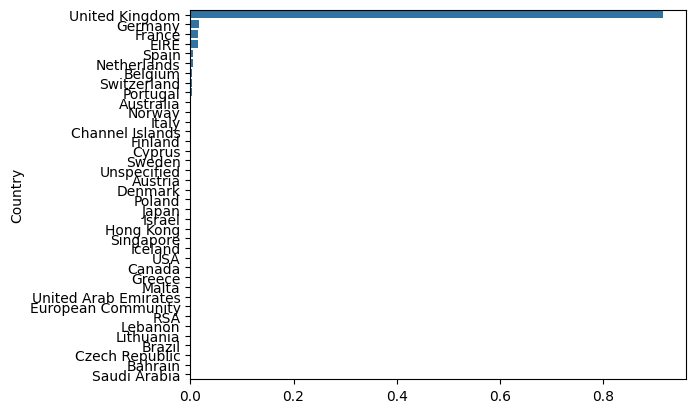

In [ ]:
sns.barplot(x=topcoun.values,y=topcoun.index)

<Axes: xlabel='Quantity', ylabel='Count'>

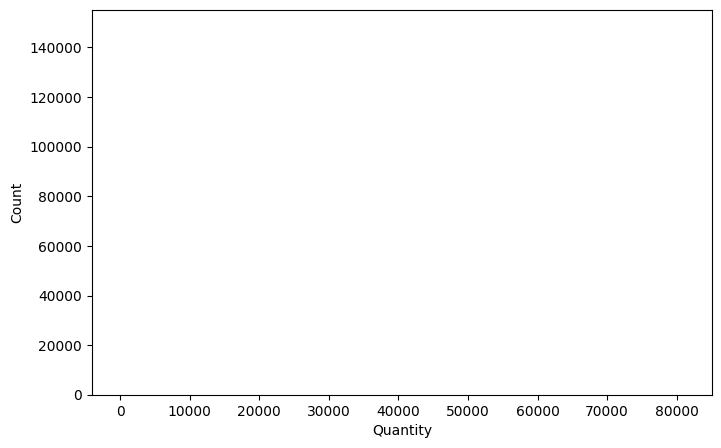

In [ ]:
#quantity distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Quantity"])

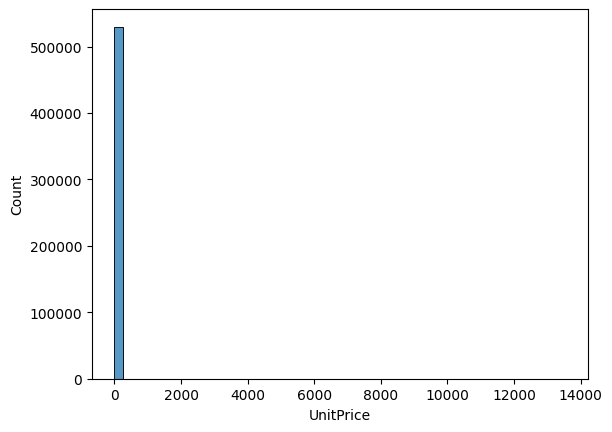

In [ ]:
#unit prize
sns.histplot(df['UnitPrice'],bins=50)
plt.show()

In [ ]:
top_products= (
    df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
)

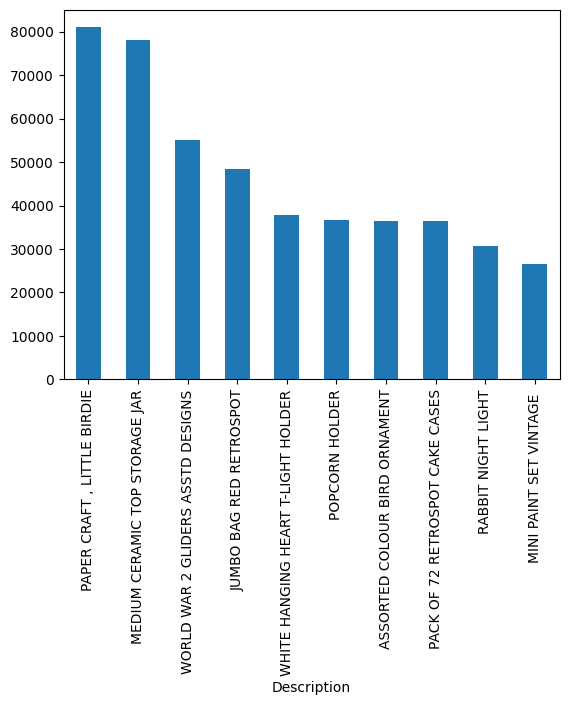

In [ ]:
top_products.plot(kind='bar')
plt.show()

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month']=df['InvoiceDate'].dt.to_period('M')

In [ ]:
monthly_sales = (
    df.groupby('Month')['TotalPrice']
      .sum()
)

In [ ]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

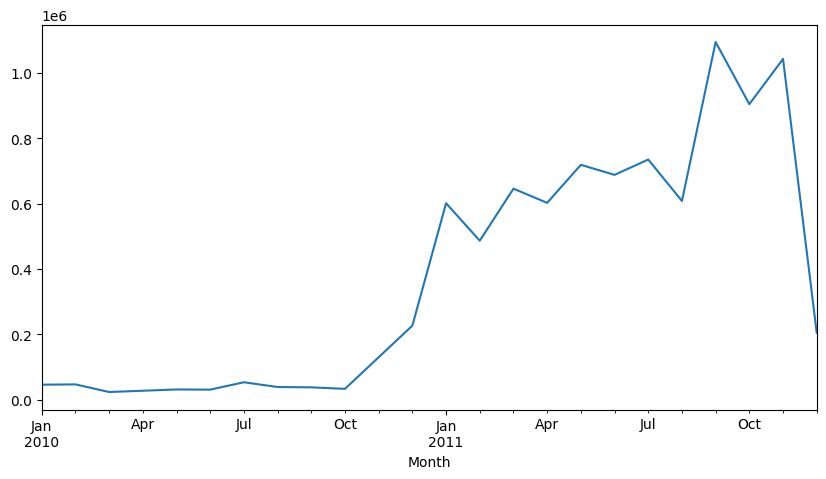

In [ ]:
monthly_sales.plot(figsize=(10,5))
plt.show()

In [ ]:
top_customers = (
    df.groupby('CustomerID')['TotalPrice']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

,TotalPrice
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194550.79
16446.0,168472.50
14911.0,143825.06
12415.0,124914.53
14156.0,117379.63
17511.0,91062.38
16029.0,81024.84


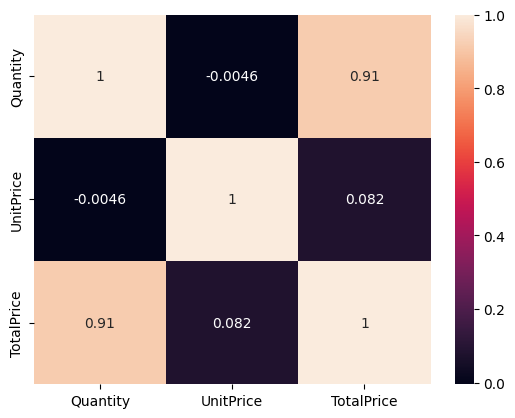

In [ ]:
sns.heatmap(
    df[['Quantity','UnitPrice','TotalPrice']]
    .corr(),
    annot=True
)
plt.show()

In [ ]:
topcoun=df['Country'].value_counts(10)

In [ ]:
snap_date=df['InvoiceDate'].max()+pd.Timedelta(days=1)
snap_date

Timestamp('2011-12-11 17:19:00')

In [ ]:
#create rfm
rfm=df.groupby('CustomerID').agg({
    'InvoiceDate':lambda x:(snap_date-x.max()).days,
    'InvoiceNo':'count',
    'TotalPrice':'sum'
})
rfm

,InvoiceDate,InvoiceNo,TotalPrice
CustomerID,,,
12346.0,327,1,77183.60
12347.0,41,182,4310.00
12348.0,77,31,1797.24
12349.0,20,73,1757.55
12350.0,312,17,334.40
...,...,...,...
18280.0,161,10,180.60
18281.0,5,7,80.82
18282.0,217,12,178.05


In [ ]:
rfm.columns=['Recency','Frequency', 'Monetary']

In [ ]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,327,1,77183.60
12347.0,41,182,4310.00
12348.0,77,31,1797.24
12349.0,20,73,1757.55
12350.0,312,17,334.40


In [ ]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,106.470954,91.720609,2054.266460
std,115.082161,228.785094,8989.230441
min,1.000000,1.000000,3.750000
25%,23.000000,17.000000,307.415000
50%,62.000000,41.000000,674.485000
75%,162.750000,100.000000,1661.740000
max,698.000000,7847.000000,280206.020000


array([[<Axes: title={'center': 'Recency'}>,
        <Axes: title={'center': 'Frequency'}>],
       [<Axes: title={'center': 'Monetary'}>, <Axes: >]], dtype=object)

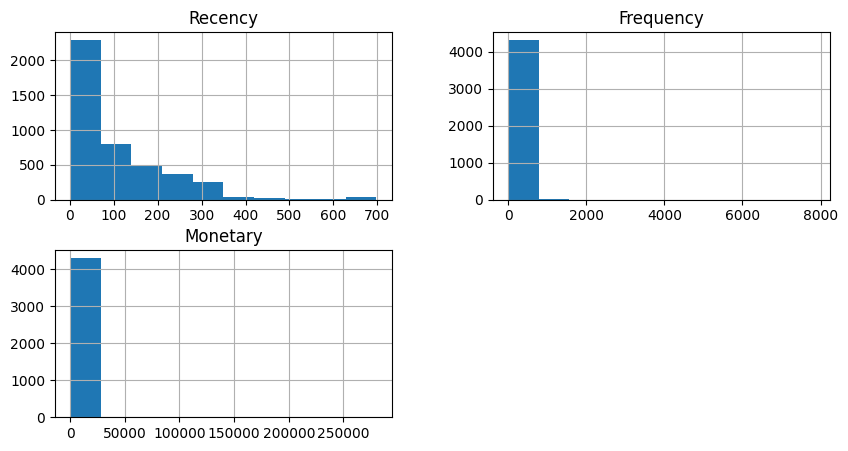

In [ ]:
rfm.hist(figsize=(10,5))

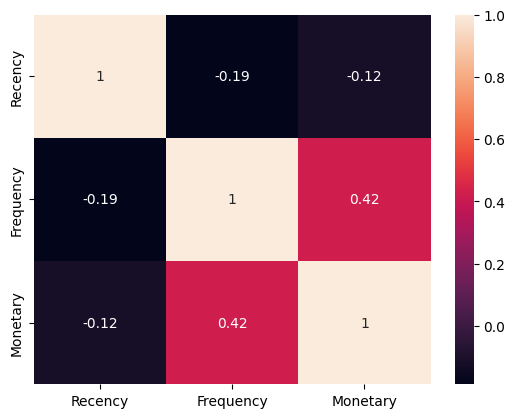

In [ ]:
sns.heatmap(rfm.corr(),annot=True)
plt.show()

In [ ]:
rfm.shape



(4338, 3)

In [ ]:
len(rfm[rfm['Monetary']<=0])

0

In [ ]:
(rfm['Monetary']<=0).sum()

np.int64(0)

Customers with non-positive monetary value were removed as they represented returns, refunds, or adjustment transactions and did not contribute to revenue-generating customer segments.

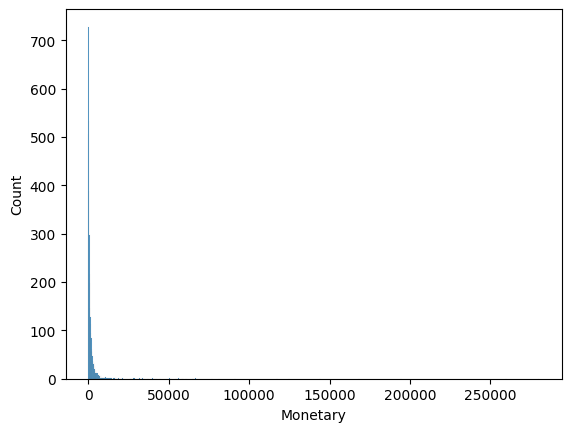

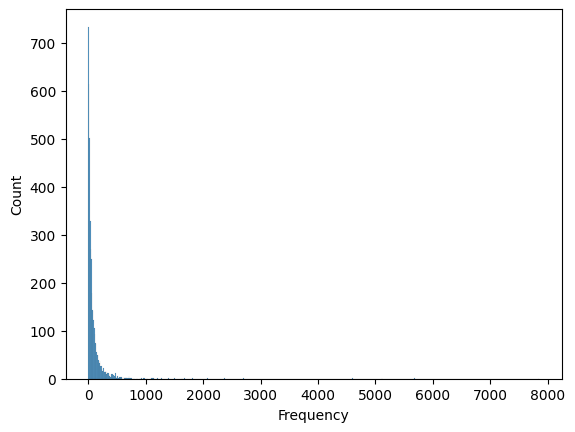

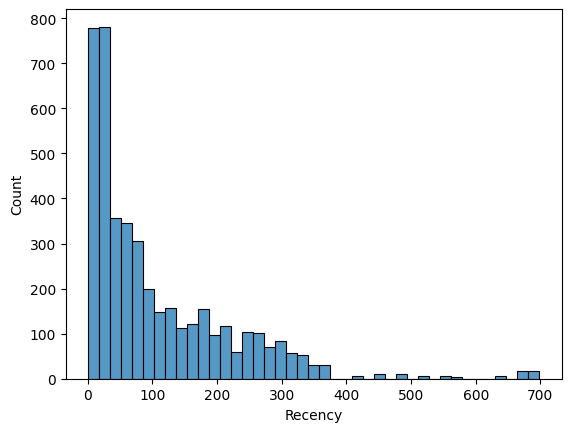

In [ ]:


sns.histplot(rfm['Monetary'])
plt.show()

sns.histplot(rfm['Frequency'])
plt.show()

sns.histplot(rfm['Recency'])
plt.show()

In [ ]:
rfm=rfm[rfm['Monetary']>0]

In [ ]:
rfm.shape

(4338, 3)

In [ ]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,106.470954,91.720609,2054.266460
std,115.082161,228.785094,8989.230441
min,1.000000,1.000000,3.750000
25%,23.000000,17.000000,307.415000
50%,62.000000,41.000000,674.485000
75%,162.750000,100.000000,1661.740000
max,698.000000,7847.000000,280206.020000


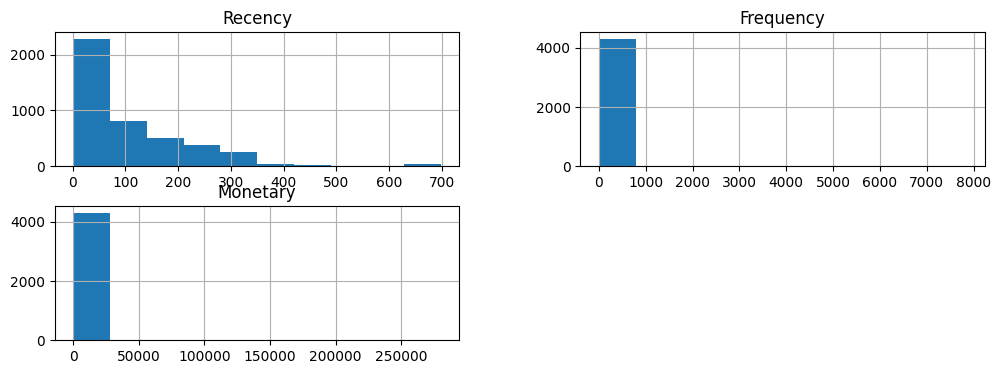

In [ ]:
rfm.hist(figsize=(12,4))
plt.show()

In [ ]:
rfm_log=rfm.copy()
rfm_log['Recency']=np.log1p(rfm_log['Recency'])
rfm_log['Frequency']=np.log1p(rfm_log['Frequency'])
rfm_log['Monetary']=np.log1p(rfm_log['Monetary'])

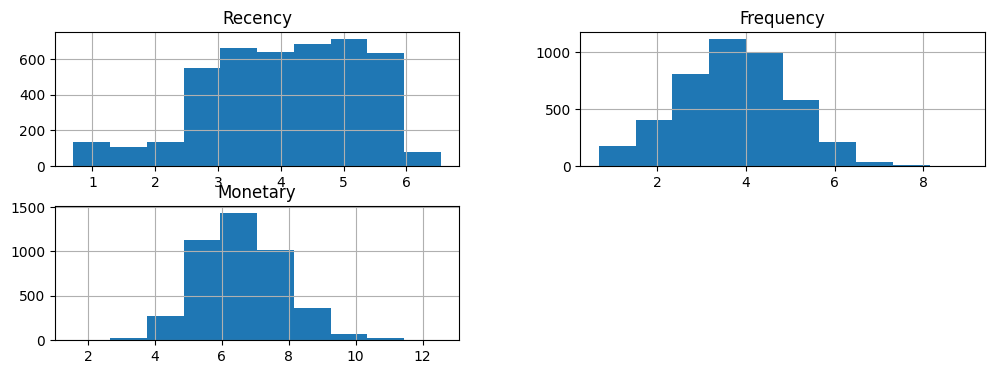

In [ ]:
rfm_log.hist(figsize=(12,4))
plt.show()

In [ ]:
rfm_log.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,4.046120,3.737143,6.593627
std,1.256871,1.250560,1.257578
min,0.693147,0.693147,1.558145
25%,3.178054,2.890372,5.731446
50%,4.143135,3.737670,6.515431
75%,5.098337,4.615121,7.416222
max,6.549651,8.968014,12.543284


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
rfm_scaled=scaler.fit_transform(rfm_log)

In [ ]:
rfm_scaled[:5]

array([[ 1.39003531, -2.4343873 ,  3.70622476],
       [-0.24543924,  1.17748295,  1.41184341],
       [ 0.2471415 , -0.21705358,  0.7164889 ],
       [-0.79698904,  0.45338686,  0.6987394 ],
       [ 1.35278741, -0.6771919 , -0.6189622 ]])

In [ ]:
from sklearn.cluster import KMeans
wcss=[]

for k in range(2,11):
  kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
  kmeans.fit(rfm_scaled)
  wcss.append(kmeans.inertia_)

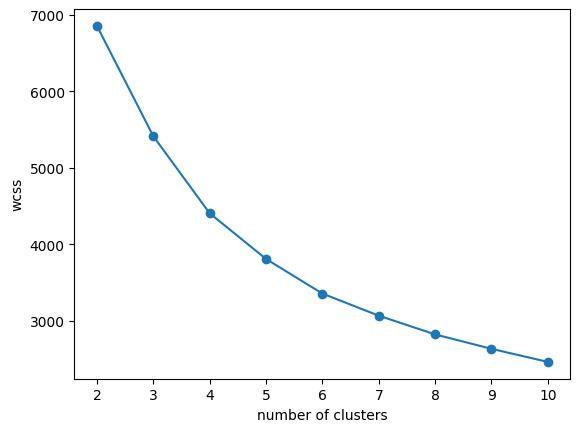

In [ ]:
plt.plot(range(2,11),wcss,marker='o')
plt.xlabel('number of clusters')
plt.ylabel('wcss')
plt.show()

In [ ]:
print(wcss)

[6853.171183202597, 5412.02610598102, 4405.760064081694, 3808.409381664932, 3356.5122274984788, 3067.5817048128406, 2822.979633601696, 2634.655434652074, 2463.5237087575624]


In [ ]:
from sklearn.metrics import silhouette_score
for k in range(2,11):
  kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
  label=kmeans.fit_predict(rfm_scaled)
  score=silhouette_score(rfm_scaled,label)

  print(f"K={k},Silhouette Score={score:4f}")

K=2,Silhouette Score=0.398751
K=3,Silhouette Score=0.294492
K=4,Silhouette Score=0.303247
K=5,Silhouette Score=0.272496
K=6,Silhouette Score=0.273966
K=7,Silhouette Score=0.258545
K=8,Silhouette Score=0.262924
K=9,Silhouette Score=0.256176
K=10,Silhouette Score=0.263384


In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

Although K=2 produced the highest silhouette score, K=4 was selected to obtain more actionable customer segments for business decision-making.

In [ ]:
rfm.groupby('Cluster').agg({
    'Recency':['mean','median'],
    'Frequency':['mean','median'],
    'Monetary':['mean','median']
}

)

Recency          Frequency            Monetary          
               mean median        mean median         mean    median
Cluster                                                             
0         21.414607   20.0   46.986517   40.0   740.140663   632.620
1        193.778287  177.5   13.426606   12.0   272.186056   219.455
2         23.241266   18.0  277.790393  189.5  6941.728133  3221.035
3        137.304739  110.0   68.666667   55.0  1256.568940   869.995

<Axes: xlabel='Recency', ylabel='Frequency'>

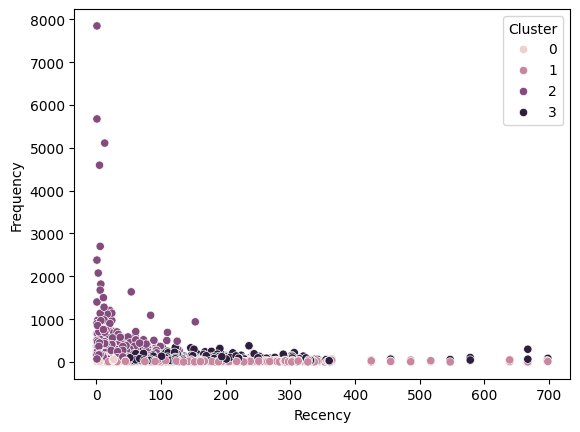

In [ ]:
sns.scatterplot(data=rfm,x='Recency',y='Frequency',hue='Cluster')

In [ ]:
segment_map={
    0:'Loyal Customers',
    1:'At-risk Customers',
    2:'VIP Customers',
    3:'Potential Loyalists'
}
rfm["segment"]=rfm['Cluster'].map(segment_map)